In [1]:
from __future__ import print_function
#%matplotlib inline
#import argparse
import os
import random
import time
import torch
import torch.nn as nn
#import torch.nn.parallel
#import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
#import matplotlib.animation as animation
#from IPython.display import HTML
import torchvision
import torchvision.transforms as transforms

# Set random seed for reproducibility
randomSeed = 10
#manualSeed = random.randint(1, 10000) # use if you want new results
#print("Random Seed: ", manualSeed)
random.seed(randomSeed)
#torch.manual_seed(manualSeed)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Root directory for dataset
dataroot = "./data"

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 64

# Number of channels in the training images. For color images this is 3
nc = 1   # 3 for color

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Number of training epochs
num_epochs = 10

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparam for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

In [4]:
# We can use an image folder dataset the way we have it setup.
# Create the dataset
transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5,), (0.5,))])
dataset = torchvision.datasets.MNIST(root=dataroot, train=True,
                                       download=True, transform=transform)
#dataset = dset.ImageFolder(root=dataroot,
#                           transform=transforms.Compose([
#                               transforms.Resize(image_size),
#                               transforms.CenterCrop(image_size),
#                               transforms.ToTensor(),
#                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
#                           ]))

100%|██████████| 9912422/9912422 [00:00<00:00, 235684628.72it/s]

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw


100%|██████████| 28881/28881 [00:00<00:00, 42743716.95it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 82157943.84it/s]

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 11127645.31it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [5]:
# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

In [6]:
device

device(type='cuda', index=0)

In [7]:
classes = ('0', '1', '2', '3',
           '4', '5', '6', '7', '8', '9')
examples = enumerate(dataloader)
batch_idx, (example_data, example_targets) = next(examples)
example_data.shape


torch.Size([128, 1, 64, 64])

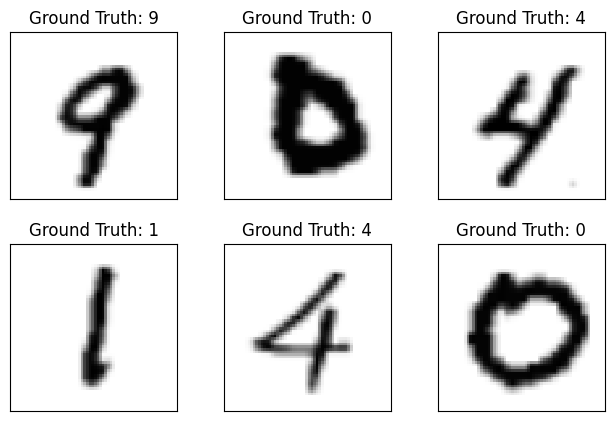

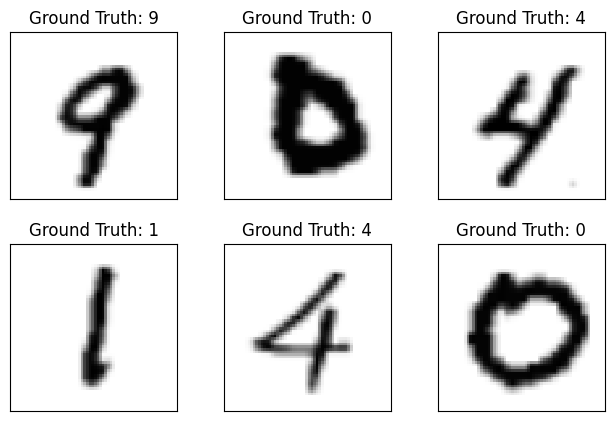

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(1-example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
fig

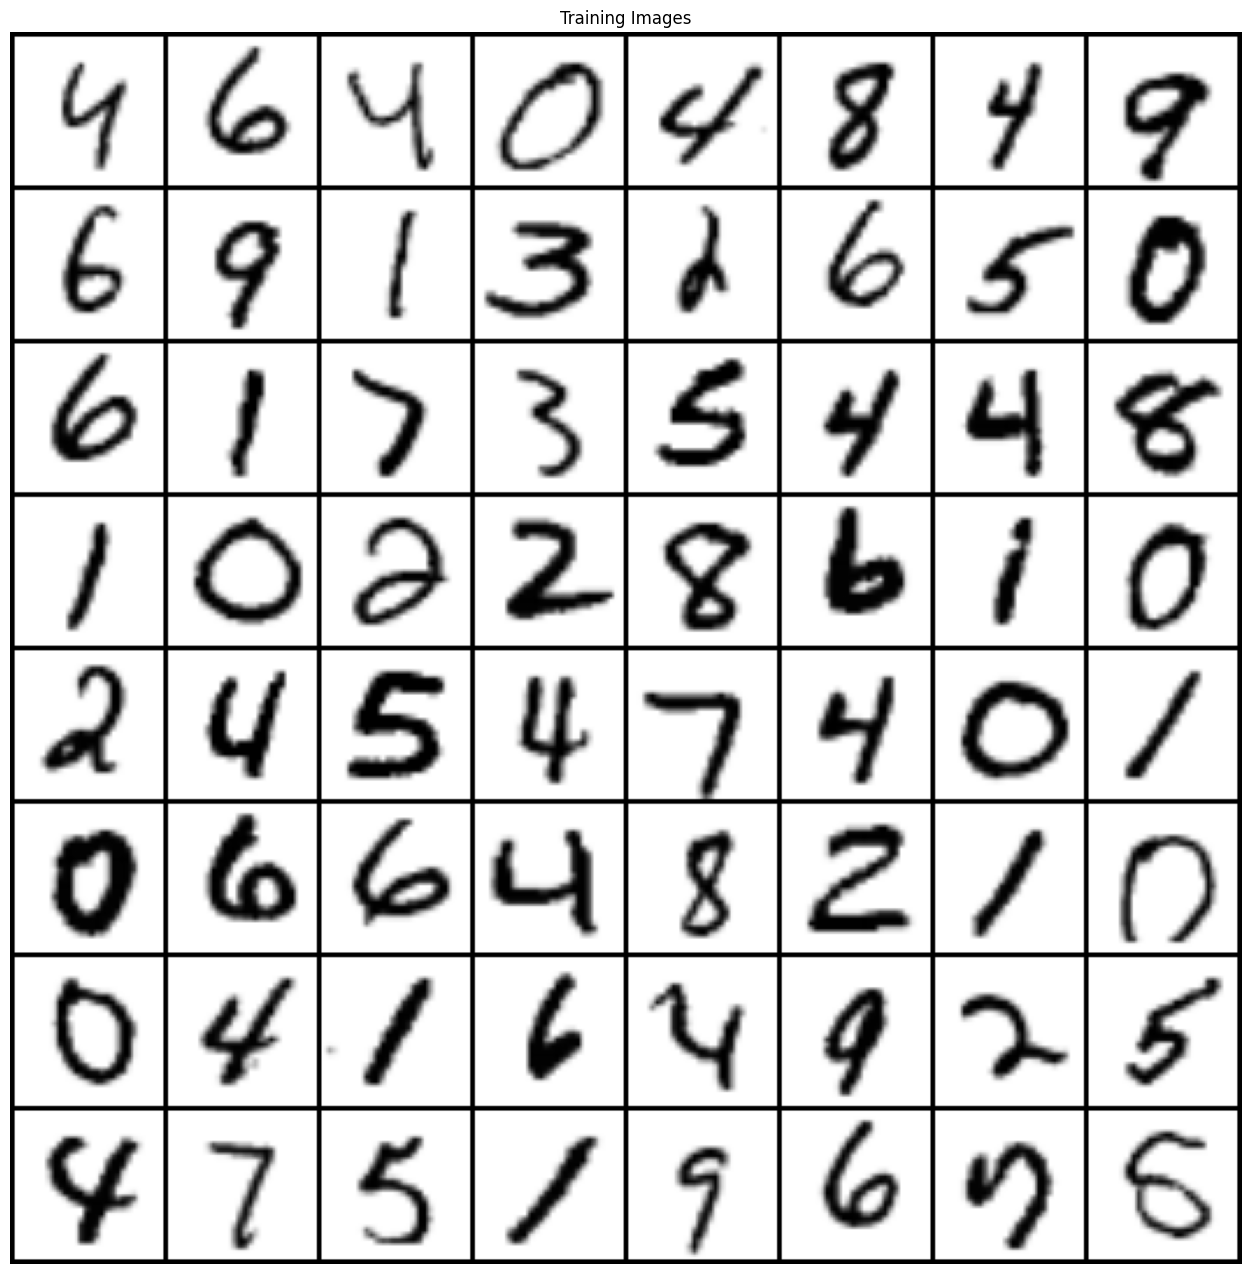

In [9]:
# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(16,16))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(1-real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
#torchvision.utils.make_grid(tensor: Union[torch.Tensor, List[torch.Tensor]], nrow: int = 8, padding: int = 2,
#   normalize: bool = False, range: Optional[Tuple[int, int]] = None, scale_each: bool = False, pad_value: int = 0)
#   → torch.Tensor

In [28]:
# weights initialization called by Gnet and Dnet
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)  # (0.0,0.02)
        nn.init.constant_(m.bias.data, 0)

In [29]:
# Generator Code

class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d( nz, ngf * 16, 4, 1, 0, bias=True),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True),
            # output size. (ngf*16=1024) x 4 x 4
            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # output size. (ngf*8=512) x 8 x 8
            nn.ConvTranspose2d( ngf * 8, ngf * 4, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # output size. (ngf*4=256) x 16 x 16
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            # output size. (ngf*2=128) x 32 x 32
            nn.ConvTranspose2d( ngf * 2, nc, 4, 2, 1, bias=True),
            nn.Tanh()
            # output size. (nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

In [38]:
# Create the generator
Gnet = Generator(ngpu).to(device)
Gnet.apply(weights_init)


Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): Tanh()
  )
)

In [31]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf * 2, 4, 2, 1, bias=True),
            nn.LeakyReLU(0.2, inplace=True),
            # output size. (ndf*2=128) x 32 x 32
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # output size. (ndf*4=256) x 16 x 16
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # output size. (ndf*8) x 8 x 8
            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=True),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            # output size. (ndf*16=1024) x 4 x 4
            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=True),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [37]:
# Create the Discriminator
Dnet = Discriminator(ngpu).to(device)
Dnet.apply(weights_init)


Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(1024, 1, kernel_size=(4, 4), stride=(1, 1))
    (12): Sigmoid()
  )
)

In [39]:
# Initialize BCELoss function
criterion = nn.BCELoss()

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(Dnet.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(Gnet.parameters(), lr=lr, betas=(beta1, 0.999))

In [40]:
# Training Loop

# Lists to keep track of progress
#img_list = []
G_losses = []
D_losses = []
num_epochs=10
print("Starting Training Loop...")

for epoch in range(num_epochs):
    # For each epoch
    for i, data in enumerate(dataloader, 0):
        # for each batch
        #--------------------------
        # (1) Update D network: maximize log(D(x))+log(1-D(G(z)))
        #------------------------------
        ## (A) Train with all-real batch
        Dnet.zero_grad()
        # Format batch
        real_imgs = data[0].to(device)
        # data[0]: images, data[1]: labels
        # real_imgs: [b_s, 1, image_size, image_size]
        b_s = real_imgs.size(0)
        label = torch.full((b_s,), real_label, dtype=torch.float, device=device)
        # Calculate output of D
        output = Dnet(real_imgs).view(-1)
        # Calculate loss on the real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D
        errD_real.backward()
        D_x = output.mean().item()

        ## (B)Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_s, nz, 1, 1, device=device)
        # Generate fake image batch by G
        fake = Gnet(noise)
        label.fill_(fake_label)
        # Calculate output of D
        output = Dnet(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients on this batch
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Add the gradients from the all-real and all-fake batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        # -----------------------------------------
        # (2) Update G network: maximize log(D(G(z)))
        # -------------------------------------------
        Gnet.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # because G wants to fool D, so we treat the fake as real.
        output = Dnet(fake).view(-1)
        # Calculate G's loss
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))


        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())




Starting Training Loop...
[0/10][0/469]	Loss_D: 1.8566	Loss_G: 8.1812	D(x): 0.3774	D(G(z)): 0.3721 / 0.0005
[0/10][50/469]	Loss_D: 3.6225	Loss_G: 44.1498	D(x): 0.4508	D(G(z)): 0.0000 / 0.0000
[0/10][100/469]	Loss_D: 0.7124	Loss_G: 2.9447	D(x): 0.6583	D(G(z)): 0.0011 / 0.1247
[0/10][150/469]	Loss_D: 0.8989	Loss_G: 0.9111	D(x): 0.5747	D(G(z)): 0.0461 / 0.5524
[0/10][200/469]	Loss_D: 1.4422	Loss_G: 0.8815	D(x): 0.3802	D(G(z)): 0.0102 / 0.5227
[0/10][250/469]	Loss_D: 0.8741	Loss_G: 1.0921	D(x): 0.5318	D(G(z)): 0.0283 / 0.4374
[0/10][300/469]	Loss_D: 1.2057	Loss_G: 0.4669	D(x): 0.3969	D(G(z)): 0.0283 / 0.6903
[0/10][350/469]	Loss_D: 1.1299	Loss_G: 3.3290	D(x): 0.8759	D(G(z)): 0.4916 / 0.0732
[0/10][400/469]	Loss_D: 1.0389	Loss_G: 4.2740	D(x): 0.9193	D(G(z)): 0.5324 / 0.0241
[0/10][450/469]	Loss_D: 0.5993	Loss_G: 2.6752	D(x): 0.8211	D(G(z)): 0.2798 / 0.1036
[1/10][0/469]	Loss_D: 0.8102	Loss_G: 1.4787	D(x): 0.6508	D(G(z)): 0.2357 / 0.2903
[1/10][50/469]	Loss_D: 0.6538	Loss_G: 3.4653	D(x): 0.9

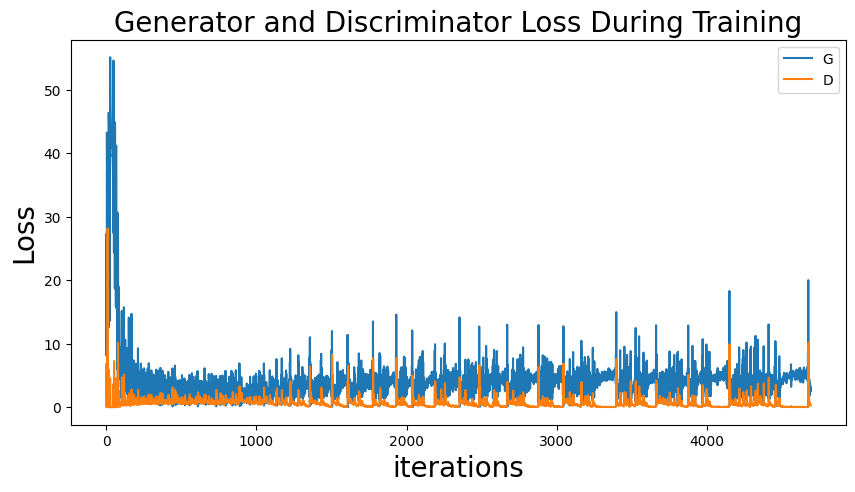

In [41]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training", fontsize=20)
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations", fontsize=20)
plt.ylabel("Loss", fontsize=20)
plt.legend()
plt.show()

plot real images and generated fake images

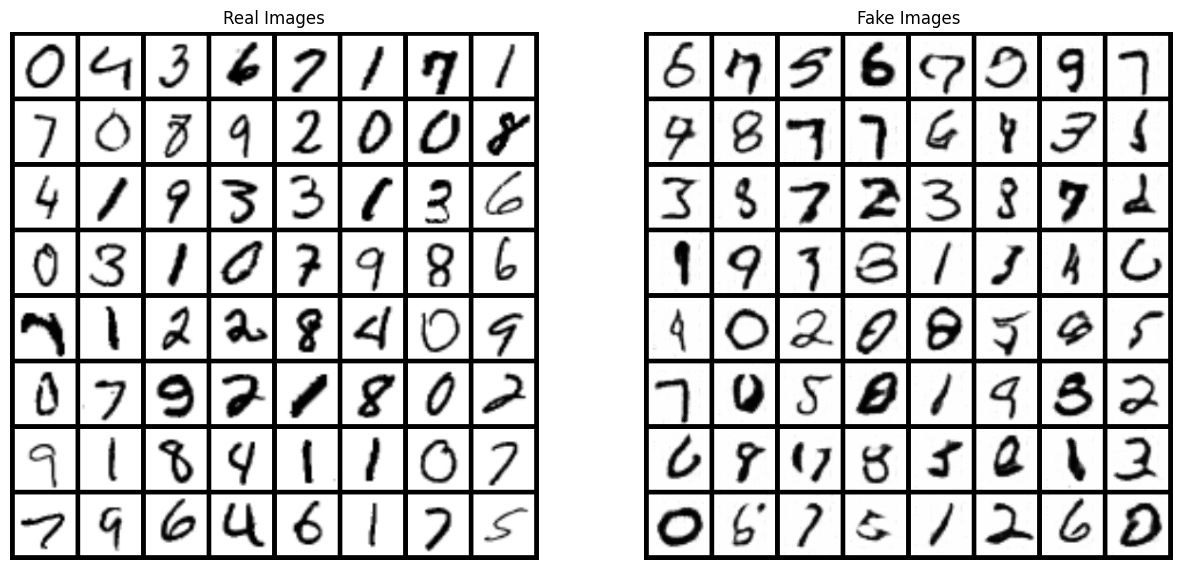

In [44]:
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
with torch.no_grad():
  fake = Gnet(fixed_noise).detach().cpu()
img = vutils.make_grid(1-fake, padding=5, normalize=True)

# Plot the real images
real_batch = next(iter(dataloader))
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(1-real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img,(1,2,0)))
plt.show()

# real images vs fake image

# save trained model parameters

In [ ]:
data_path = '/content/drive/MyDrive/ '
torch.save(Gnet.state_dict(), data_path + 'mnist_parameters_Gnet.pt')
torch.save(Dnet.state_dict(), data_path + 'mnist_parameters_Dnet.pt')

In [ ]:
G1=Generator(ngpu).to(device)

In [ ]:
fake = G1(fixed_noise).detach().cpu()

In [ ]:
img_list[-1].size()

torch.Size([3, 557, 557])

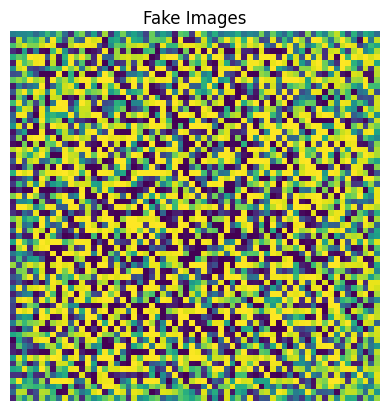

In [ ]:
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(fake[0]*0.5+0.5,(1,2,0)))
#plt.imshow(fake[0], cmap='gray', interpolation='none')
plt.show()

In [ ]:
G1.load_state_dict(torch.load(data_path
+ 'mnist_parameters_Gnet.pt'))

<All keys matched successfully>

In [ ]:
fake = G1(fixed_noise).detach().cpu()

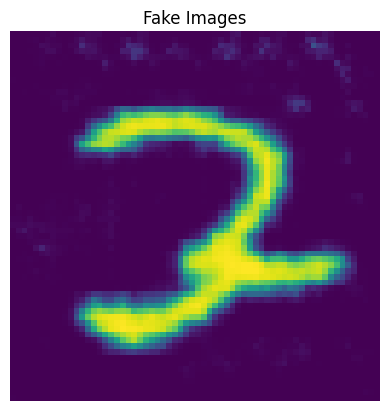

In [ ]:

plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(fake[0]*0.5+0.5,(1,2,0)))
plt.show()

In [ ]:
fake.size()

torch.Size([64, 3, 64, 64])